In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# Configuração visual do gráfico
sns.set(style="darkgrid")

# Carregando os dados
dados = pd.read_csv('queries01_data_cleaning.csv')

# 2. Tratando a coluna TotalCharges (garantindo conversão para numérico caso haja nulos)
dados['TotalCharges'] = pd.to_numeric(dados['TotalCharges'], errors='coerce').fillna(0)

# 1° pergunta: Qual o tamanho do problema???

total_clientes = len(dados)
filtro_churn = (dados['Churn'] == True)
 # Somando os valores True da coluna Churn
total_churn = filtro_churn.sum()
taxa_churn = (total_churn / total_clientes) * 100

# Calculando a perda de receita
receita_perdida_mensal = dados[filtro_churn]['MonthlyCharges'].sum()

# Calculando a perda de receita total (considerando TotalCharges)
receita_perdida_total = dados[filtro_churn]['TotalCharges'].sum()

print(f"Total de clientes: {total_clientes}")
print(f"Churn: {total_churn} ({taxa_churn:.2f}%)")
print(f"Perda Financeira Mensal Estimada: ${receita_perdida_mensal:,.2f}")
print(f"Perda Financeira Total: ${receita_perdida_total:,.2f}")

Total de clientes: 7043
Churn: 1869 (26.54%)
Perda Financeira Mensal Estimada: $139,130.85
Perda Financeira Total: $2,862,926.90


In [3]:
# 2° pergunta: Quem é o cliente que mais cancela? (Análise por Contrato e Tenure)

# Churn por tipo de contrato (%)
churn_contrato = dados.groupby('Contract')['Churn'].mean() * 100
print("--- Taxa de Churn por Tipo de Contrato (%) ---")
print(churn_contrato.round(2))

# Tempo médio de permanência (Tenure) de quem cancelou vs quem continuou
tenure_medio = dados.groupby('Churn')['tenure_months'].mean()
print("\n--- Média de Permanência (Meses) ---")
print(tenure_medio.round(1))

--- Taxa de Churn por Tipo de Contrato (%) ---
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

--- Média de Permanência (Meses) ---
Churn
False    37.6
True     18.0
Name: tenure_months, dtype: float64


In [10]:
# 3° pergunta: Quais produtos/serviços são os maiores responsáveis pelo churn? (Análise por Serviços Contratados)

# 1. Churn por tipo de Internet
churn_internet = dados.groupby('InternetService')['Churn'].mean() * 100
print("--- Taxa de Churn por Tipo de Internet (%) ---")
print(churn_internet.round(2))

# 2. Churn pela quantidade de serviços contratados (Usando a coluna do seu SQL!)
churn_qtd_servicos = dados.groupby('total_services')['Churn'].mean() * 100
print("\n--- Taxa de Churn por Qtd. de Serviços Contratados (%) ---")
print(churn_qtd_servicos.round(2))

--- Taxa de Churn por Tipo de Internet (%) ---
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

--- Taxa de Churn por Qtd. de Serviços Contratados (%) ---
total_services
1    10.92
2    30.97
3    44.92
4    36.48
5    31.34
6    25.55
7    22.49
8    12.41
9     5.29
Name: Churn, dtype: float64


In [12]:
# 4° pergunta: Como o aspecto financeiro afeta o cancelamento? (Análise por Receita Mensal e Total)

# 1 Churn por Método de Pagamento (%)
churn_pagamento = dados.groupby('PaymentMethod')['Churn'].mean() * 100
print("--- Taxa de Churn por Método de Pagamento (%) --- ")
print(churn_pagamento.round(2))

# 2 Churn por Fatura Digital / PaperlessBilling (%)
churn_fatura_digital = dados.groupby('PaperlessBilling')['Churn'].mean() * 100
print("\n--- Taxa de Churn por Fatura Digital / PaperlessBilling (%) ---")
print(churn_fatura_digital.round(2))    



--- Taxa de Churn por Método de Pagamento (%) --- 
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64

--- Taxa de Churn por Fatura Digital / PaperlessBilling (%) ---
PaperlessBilling
False    16.33
True     33.57
Name: Churn, dtype: float64


In [22]:
# 5° pergunta: O perfil demográfico (Gênero, Parceiro, Dependentes) afeta o Churn?

# 1 Churn por Gênero (%)
churn_genero = dados.groupby('gender')['Churn'].mean() * 100
print("--- Taxa de Churn por Gênero (%) ---")
print(churn_genero.round(2))

# 2 Churn por Possuir Parceiro/Cônjuge (Partner)
churn_parceiro = dados.groupby('Partner')['Churn'].mean() * 100
print("\n--- Taxa de Churn por Possuir Parceiro (%) ---")
print(churn_parceiro.round(2))

# 3 Churn por Possuir Dependentes (Dependents)
churn_dependentes = dados.groupby('Partner')['Churn'].mean() * 100
print("\n--- Taxa de Churn por Possuir Dependentes (%) ---")
print(churn_dependentes.round(2))


--- Taxa de Churn por Gênero (%) ---
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

--- Taxa de Churn por Possuir Parceiro (%) ---
Partner
False    32.96
True     19.66
Name: Churn, dtype: float64

--- Taxa de Churn por Possuir Dependentes (%) ---
Partner
False    32.96
True     19.66
Name: Churn, dtype: float64


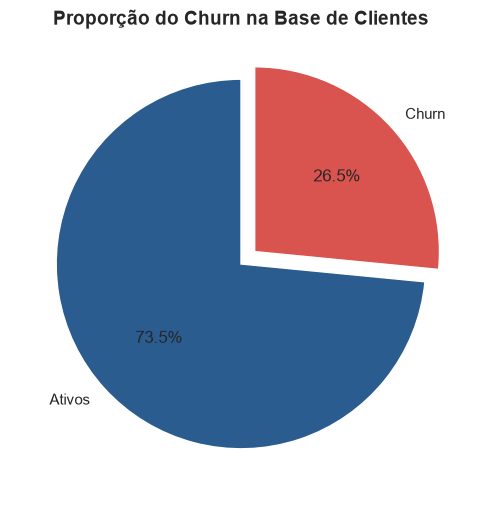

In [ ]:
# Grafico 1: Proporção de Churn
labels = ['Ativos', 'Churn']
valores = [total_clientes - total_churn, total_churn]
cores = ['#2b5c8f', '#d9534f']

plt.figure(figsize=(6, 6))
plt.pie(valores, labels=labels, autopct='%1.1f%%', startangle=90, colors=cores, explode=(0, 0.1))
plt.title('Proporção do Churn na Base de Clientes', fontsize=14, fontweight='bold')
plt.show()

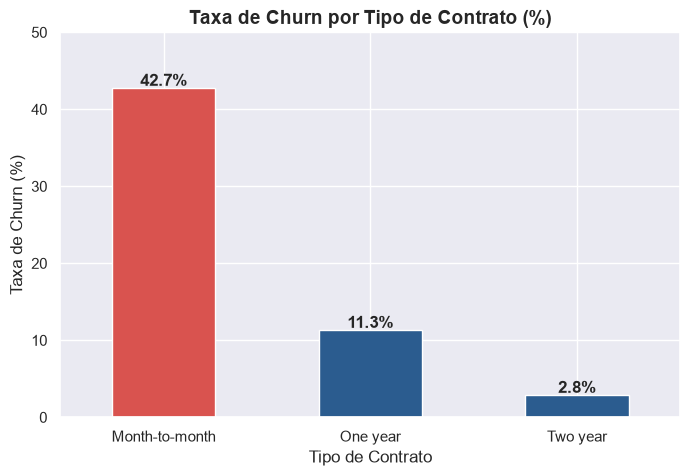

In [18]:
# Gráfico 2: Taxa de Churn por Tipo de Contrato
plt.figure(figsize=(8, 5))
ax = churn_contrato.plot(kind='bar', color=['#d9534f', '#2b5c8f', '#2b5c8f'])

plt.title('Taxa de Churn por Tipo de Contrato (%)', fontsize=14, fontweight='bold')
plt.ylabel('Taxa de Churn (%)')
plt.xlabel('Tipo de Contrato')
plt.xticks(rotation=0)

# Adicionando os rótulos de porcentagem em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.ylim(0, 50)
plt.show()

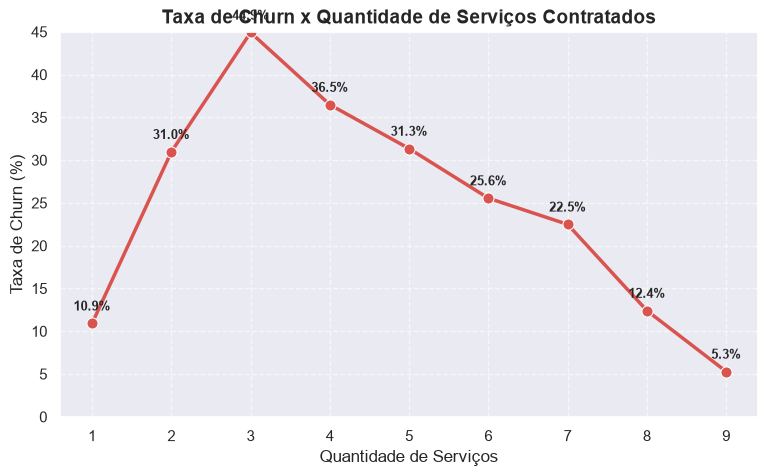

In [19]:
# Gráfico 3: Curva de Churn por Qtd de Serviços
plt.figure(figsize=(9, 5))
sns.lineplot(x=churn_qtd_servicos.index, y=churn_qtd_servicos.values, marker='o', linewidth=2.5, color='#d9534f', markersize=8)

plt.title('Taxa de Churn x Quantidade de Serviços Contratados', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Serviços')
plt.ylabel('Taxa de Churn (%)')
plt.grid(True, linestyle='--', alpha=0.6)

# Adicionando valores nos pontos da linha
for x, y in zip(churn_qtd_servicos.index, churn_qtd_servicos.values):
    plt.text(x, y + 1.5, f'{y:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.ylim(0, 45)
plt.show()

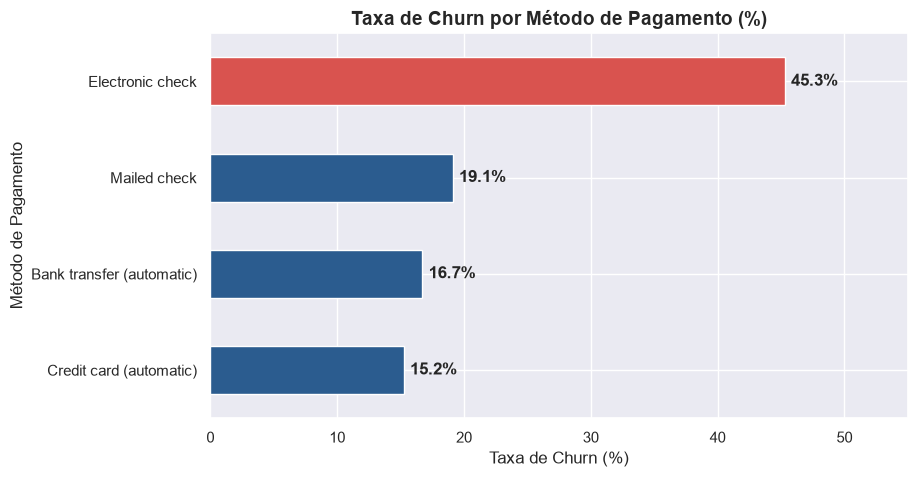

In [20]:
# Gráfico 4: Taxa de Churn por Método de Pagamento
plt.figure(figsize=(9, 5))
ax = churn_pagamento.sort_values().plot(kind='barh', color=['#2b5c8f', '#2b5c8f', '#2b5c8f', '#d9534f'])

plt.title('Taxa de Churn por Método de Pagamento (%)', fontsize=14, fontweight='bold')
plt.xlabel('Taxa de Churn (%)')
plt.ylabel('Método de Pagamento')

# Adicionando os rótulos de porcentagem ao lado das barras
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', (p.get_width() + 0.5, p.get_y() + p.get_height() / 2.),
                va='center', fontweight='bold')

plt.xlim(0, 55)
plt.show()


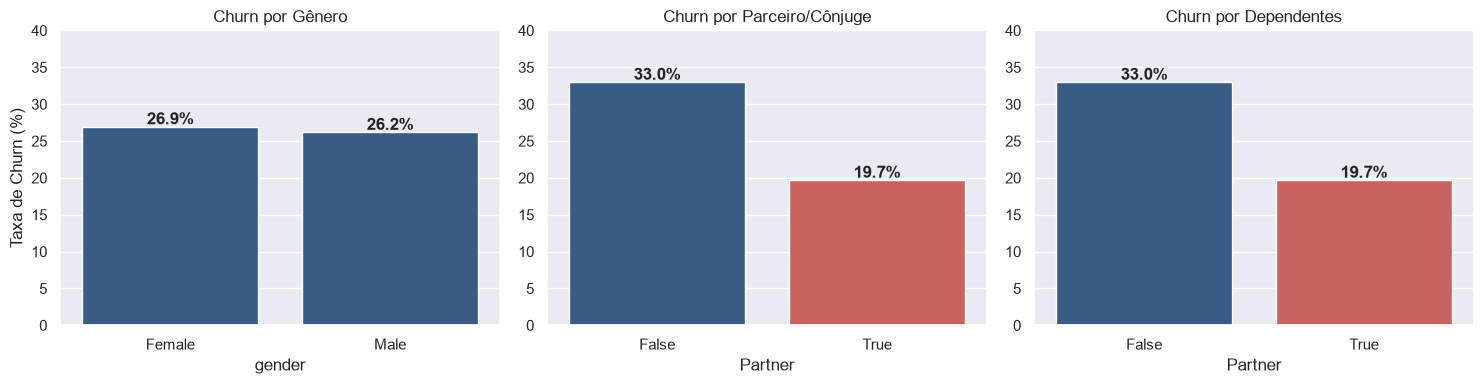

In [ ]:
# Gráfico comparativo do perfil demográfico (sem avisos de FutureWarning)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1 Gênero
sns.barplot(
    x=churn_genero.index, 
    y=churn_genero.values, 
    hue=churn_genero.index, 
    legend=False, 
    ax=axes[0], 
    palette=['#2b5c8f', '#2b5c8f']
)
axes[0].set_title('Churn por Gênero')
axes[0].set_ylabel('Taxa de Churn (%)')
axes[0].set_ylim(0, 40)

# 2 Parceiro
sns.barplot(
    x=churn_parceiro.index, 
    y=churn_parceiro.values, 
    hue=churn_parceiro.index, 
    legend=False, 
    ax=axes[1], 
    palette=['#2b5c8f', '#d9534f']
)
axes[1].set_title('Churn por Parceiro/Cônjuge')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 40)

# 3 Dependentes
sns.barplot(
    x=churn_dependentes.index, 
    y=churn_dependentes.values, 
    hue=churn_dependentes.index, 
    legend=False, 
    ax=axes[2], 
    palette=['#2b5c8f', '#d9534f']
)
axes[2].set_title('Churn por Dependentes')
axes[2].set_ylabel('')
axes[2].set_ylim(0, 40)

# Adicionando rótulos de porcentagem nas barras
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()